<h2> EDA on titanic Dataset</h2>

<h3> Importing Libraries</h3>

In [2]:
import numpy as np 
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

<h4> # Importing the dataset</h4>

In [4]:
df = pd.read_csv('train.csv')

In [5]:
# Shape of the data set(total rows and coloumns )
df.shape

(891, 12)

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# Total Coloumns
df.columns.values

array(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype=object)

## Categorical Columns

- Survived
- PClass
- Sex
- SibSp
- Parch
- Embarked

## Numerical Columns

- Age 
- Fare
- PassengerId

## Mixed Columns

- Name
- Ticket
- Cabin

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
# finding null values in each coloumn
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
# Few insights

# 1. Missing values in Age, Cabin and Embarked columns
# 2. More than 70 percent values are missing in cabin columns, will have to drop
# 3. Few columns have inappropriate data types

In [11]:
# deleting cabin column

df.drop(columns=['Cabin'],inplace=True)

In [14]:
# imputing  values in the missing coloumns ( age, embarked)
# The modern, recommended way to fill missing values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

## Changing data type for the following cols

- Survived(category)
- PClass(category)
- Sex(category)
- Age(int)
- Embarked(category)
 

In [16]:
df['Survived']=df['Survived'].astype('category')
df['Pclass']=df['Pclass'].astype('category')
df['Sex']=df['Sex'].astype('category')
df['Age']=df['Age'].astype('int')
df['Embarked']=df['Embarked'].astype('category')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    int64   
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(4), float64(1), int64(4), object(2)
memory usage: 52.8+ KB


In [20]:
# describe function 
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.544332,0.523008,0.381594,32.204208
std,257.353842,13.013778,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,29.000000,0.000000,0.000000,14.454200
75%,668.500000,35.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


<h4>Plotting the bar Graph to see how many survived and how many coudnt</h4>

Out of 891, 62% people died in the accident


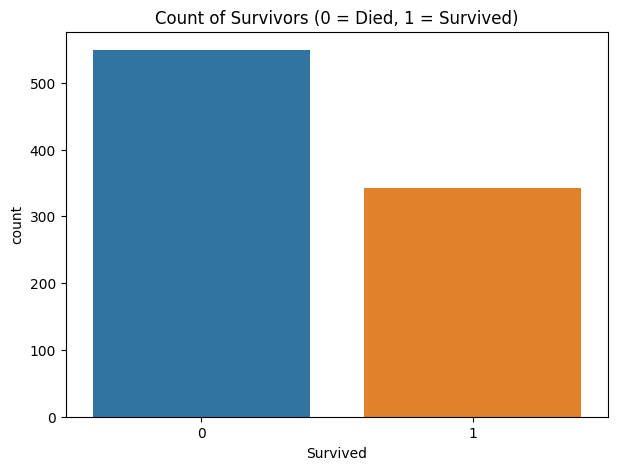

In [26]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Survived', hue='Survived', palette='tab10', legend=False)

plt.title('Count of Survivors (0 = Died, 1 = Survived)')
print("Out of 891, {}% people died in the accident".format(death_percent))
plt.show()

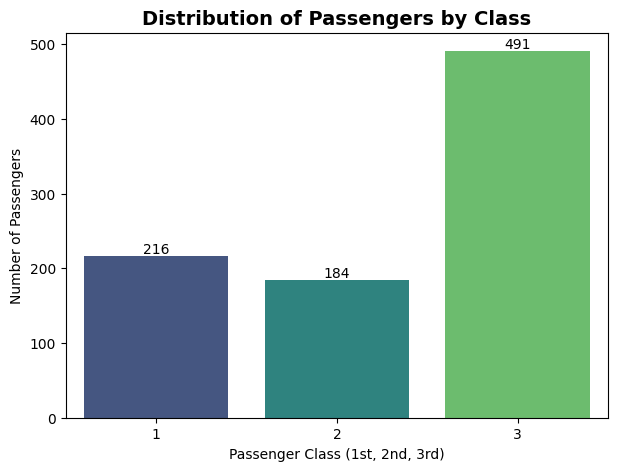

In [31]:
#people Traveling in different Passanger Classes 

plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x='Pclass', hue='Pclass', palette='viridis', legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Passengers by Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class (1st, 2nd, 3rd)')
plt.ylabel('Number of Passengers')

plt.show()

C:\Users\Tashkeel\AppData\Local\Temp\ipykernel_14732\2411320392.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female (Total 314)', 'Male (Total 577)'])


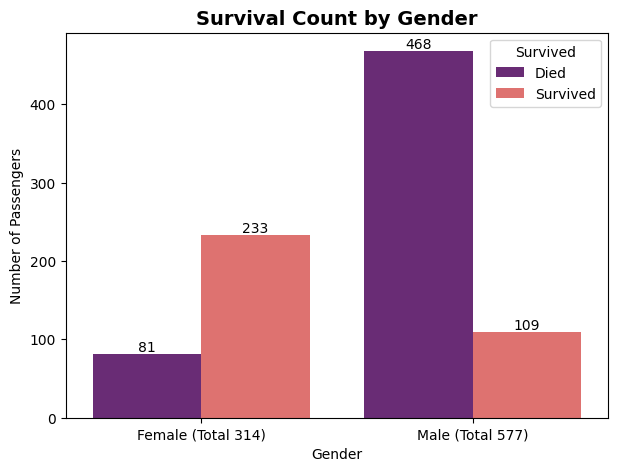

In [33]:
# Survival rate by Gender
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x='Sex', hue='Survived', palette='magma')

for container in ax.containers:
    ax.bar_label(container)

ax.set_xticklabels(['Female (Total 314)', 'Male (Total 577)'])

plt.title('Survival Count by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['Died', 'Survived'])

plt.show()

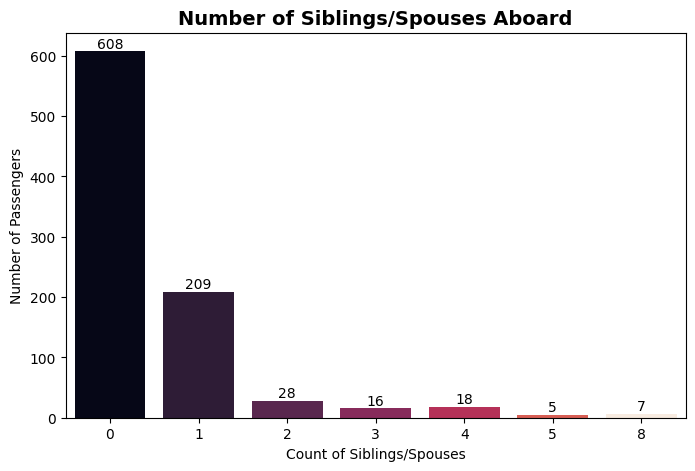

In [36]:
# People TRaveling with their sibling/spuses 
plt.figure(figsize=(8, 5))


ax = sns.countplot(data=df, x='SibSp', hue='SibSp', palette='rocket', legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Number of Siblings/Spouses Aboard', fontsize=14, fontweight='bold')
plt.xlabel('Count of Siblings/Spouses')
plt.ylabel('Number of Passengers')

plt.show()

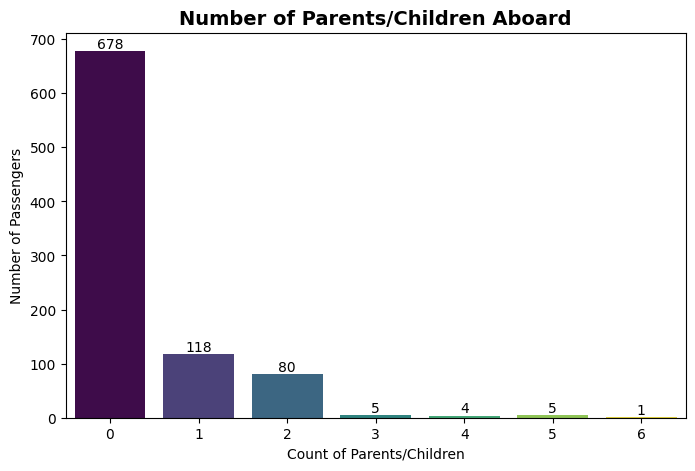

In [37]:
# Number of Parents/Children Aboard
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x='Parch', hue='Parch', palette='viridis', legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Number of Parents/Children Aboard', fontsize=14, fontweight='bold')
plt.xlabel('Count of Parents/Children')
plt.ylabel('Number of Passengers')

plt.show()

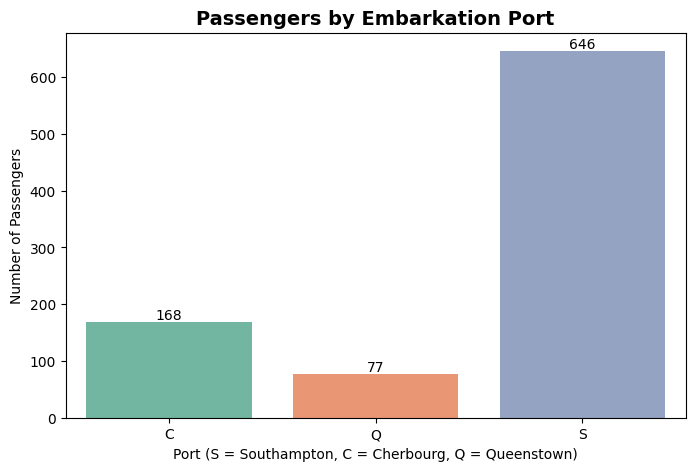

In [39]:
#Embark coloumn which city passagers are heading towards
plt.figure(figsize=(8, 5))


ax = sns.countplot(data=df, x='Embarked', hue='Embarked', palette='Set2', legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Passengers by Embarkation Port', fontsize=14, fontweight='bold')
plt.xlabel('Port (S = Southampton, C = Cherbourg, Q = Queenstown)')
plt.ylabel('Number of Passengers')

plt.show()

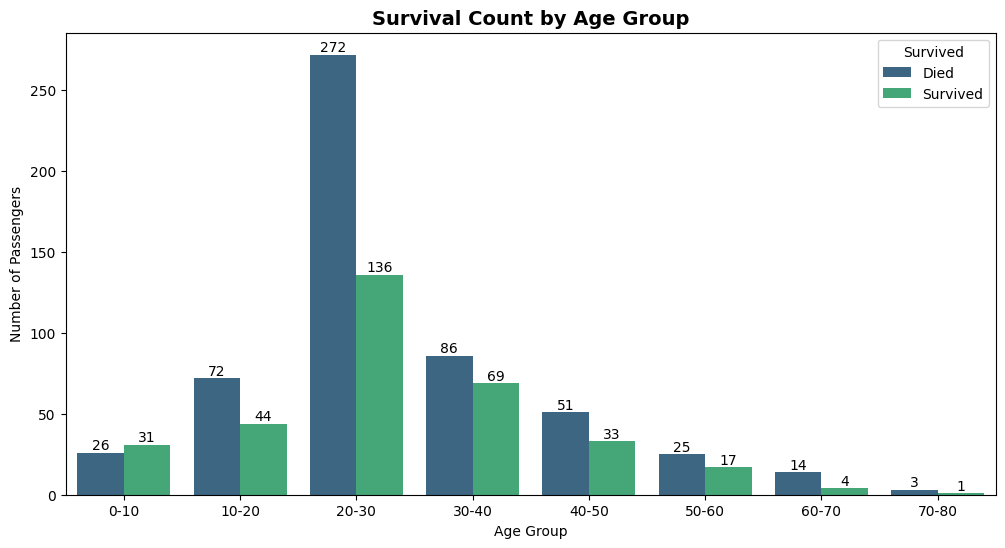

In [45]:
# Age coloumn graph
# categorizing age Groups
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80']

# Creating new coloumn Age_Group
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)


plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='Age_Group', hue='Survived', palette='viridis')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Survival Count by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['Died', 'Survived'])

plt.show()

<h4>BOXPLOT for age</h4>

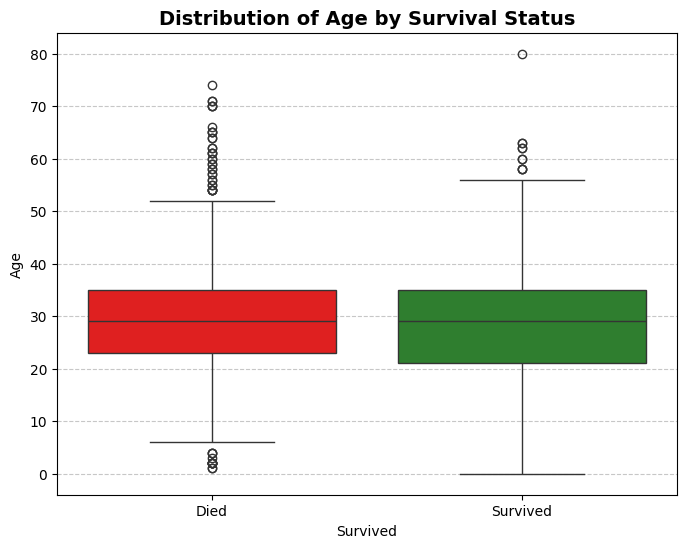

In [46]:
# if survivors were generally younger than those who died.?
plt.figure(figsize=(8, 6))


# x is categorical (Survived), y is numerical (Age)
sns.boxplot(data=df, x='Survived', y='Age', palette={0: "red", 1: "forestgreen"}, hue='Survived', legend=False)


plt.title('Distribution of Age by Survival Status', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()